<a href="https://colab.research.google.com/github/SebaAcunaC/YOLO11-Vigilancia-Urbana-USACH/blob/main/Prueba_de_YOLO11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Registro de Prueba de Concepto (Primera semana)
**Objetivo:** Validar la compatibilidad de la arquitectura YOLO11 y la infraestructura de Google Colab para la detección de personas en tiempo real.

**Entorno de Ejecución:** Uso de GPU Tesla T4 para optimizar la velocidad de inferencia, crucial para métricas de tiempo de respuesta exigidas en telecomunicaciones.

**Modelo Utilizado:** yolo11n.pt (Nano), seleccionado por ser el estado del arte en eficiencia y precisión para esta versión.

**Filtro de Clase:** Implementación del parámetro classes=0 para aislar específicamente la detección de seres humanos.

**Resultados:** Validación exitosa tanto en imágenes estáticas como en flujo de video mediante Webcam, logrando detecciones con confianza superior al 50%.

# Implementación de YOLO11:
Se utilizó la librería oficial de ultralytics para cargar el modelo pre-entrenado yolo11n.pt (versión Nano), seleccionada por su alta eficiencia en términos de latencia y precisión.

In [ ]:
!pip install ultralytics

# Detección Estática:
Se realizó una prueba de detección sobre imágenes cargadas, donde el modelo identificó con éxito la clase "person" (clase 0), dibujando los cuadros delimitadores (bounding boxes) con niveles de confianza superiores al 50%.


WARNING ⚠️ Download failure, retrying 1/3 https://media.istockphoto.com/id/1480574526/es/foto/personas-multigeneracionales-felices-divirtiéndose-sentadas-en-el-césped-de-un-parque-público.jpg... 'ascii' codec can't encode character '\xe9' in position 71: ordinal not in range(128)
image 1/1 /content/personas-multigeneracionales-felices-divirtiéndose-sentadas-en-el-césped-de-un-parque-público.jpg: 448x640 11 persons, 161.7ms
Speed: 5.4ms preprocess, 161.7ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)


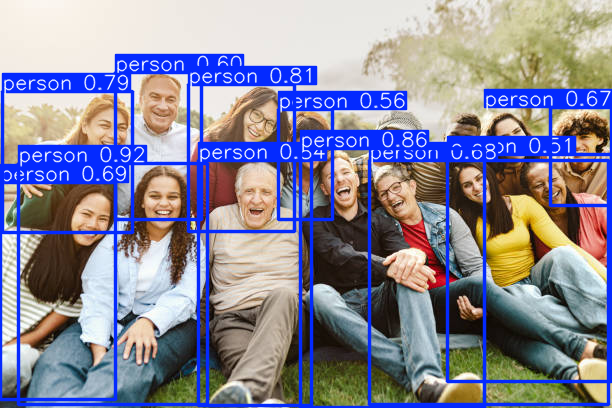

In [ ]:
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import cv2

# 1. Cargar el modelo YOLO11 versión nano (el más rápido para pruebas)
model = YOLO('yolo11n.pt')

# 2. Ejecutar la detección en una imagen o video
# Nota: Si no tienes un archivo a mano, puedes poner una URL de una imagen de internet
results = model.predict(source="https://media.istockphoto.com/id/1480574526/es/foto/personas-multigeneracionales-felices-divirtiéndose-sentadas-en-el-césped-de-un-parque-público.jpg?s=612x612&w=0&k=20&c=ijIadS4ax0rpKdgAeBsOTpt9LXGImLhG7nOk5qUcscg=", classes=0, conf=0.5)

# 3. Mostrar el resultado en pantalla
for r in results:
    im_array = r.plot()  # Dibuja los cuadros y etiquetas
    cv2_imshow(im_array) # Muestra la imagen en Colab

# Detección Dinámica (Webcam):
Se integró un script de JavaScript para habilitar el acceso a la cámara local desde la nube. Esto permitió validar que el modelo es capaz de procesar flujos de video y detectar personas en un entorno real de prueba.

Prepara tu pose...


<IPython.core.display.Javascript object>


image 1/1 /content/photo.jpg: 480x640 1 person, 190.2ms
Speed: 2.9ms preprocess, 190.2ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)


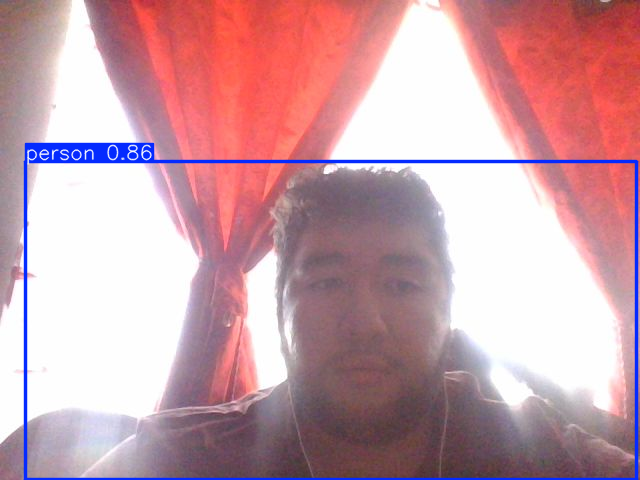

In [ ]:
import numpy as np
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# 1. Cargamos YOLO11
model = YOLO('yolo11n.pt')

# 2. Función de JavaScript para activar la cámara
def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capturar';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

# 3. Ejecución: Capturar foto y detectar
try:
  print("Prepara tu pose...")
  filename = take_photo()

  # Hacer la detección con YOLO11
  # classes=0 detecta solo personas
  results = model.predict(source=filename, classes=0, conf=0.4)

  # Mostrar resultado
  for r in results:
      im_array = r.plot()
      cv2_imshow(im_array)

except Exception as err:
  print(str(err))